In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('all_stocks_5yr.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 40.8 MB


In [4]:
df.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(619040, 7)

In [8]:
df.isnull().sum()

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [9]:
df.isna().sum()

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [10]:
df['Name'].apply(lambda x: x != x.strip() or x != x.upper()).sum()

np.int64(0)

In [11]:
df['Name'].nunique(), df['date'].min(), df['date'].max()

(505, '2013-02-08', '2018-02-07')

In [12]:
df.shape

(619040, 7)

In [13]:
df = df.dropna()
df.shape

(619029, 7)

In [14]:
wide = df.pivot(index='date', columns='Name', values='close')
wide.shape

(1259, 505)

In [15]:
wide.head()

Name,A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,...,XL,XLNX,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2013-02-08,45.08,14.75,78.90,67.8542,36.25,46.89,34.41,73.31,39.12,45.70,...,28.24,37.51,88.61,42.87,31.84,27.09,65.30,75.85,24.14,33.05
2013-02-11,44.60,14.46,78.39,68.5614,35.85,46.76,34.26,73.07,38.64,46.08,...,28.31,37.46,88.28,42.84,31.96,27.46,64.55,75.65,24.21,33.26
2013-02-12,44.62,14.27,78.60,66.8428,35.42,46.96,34.30,73.37,38.89,46.27,...,28.41,37.58,88.46,42.87,31.84,27.95,64.75,75.44,24.49,33.74
2013-02-13,44.75,14.66,78.97,66.7156,35.27,46.64,34.46,73.56,38.81,46.26,...,28.42,37.80,88.67,43.08,32.00,28.26,64.41,76.00,24.74,33.55
2013-02-14,44.58,13.99,78.84,66.6556,36.57,46.77,34.70,73.13,38.61,46.54,...,28.22,38.44,88.52,42.91,32.12,28.47,63.89,76.34,24.63,33.27


In [16]:
wide.isna().sum().sum()

np.int64(16766)

In [17]:
returns = wide.pct_change()
returns = returns.iloc[1:]
returns.shape

(1258, 505)

In [18]:
returns.head()

Name,A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,...,XL,XLNX,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2013-02-11,-0.010648,-0.019661,-0.006464,0.010422,-0.011034,-0.002772,-0.004359,-0.003274,-0.012270,0.008315,...,0.002479,-0.001333,-0.003724,-0.000700,0.003769,0.013658,-0.011485,-0.002637,0.002900,0.006354
2013-02-12,0.000448,-0.013140,0.002679,-0.025067,-0.011994,0.004277,0.001168,0.004106,0.006470,0.004123,...,0.003532,0.003203,0.002039,0.000700,-0.003755,0.017844,0.003098,-0.002776,0.011565,0.014432
2013-02-13,0.002913,0.027330,0.004707,-0.001903,-0.004235,-0.006814,0.004665,0.002590,-0.002057,-0.000216,...,0.000352,0.005854,0.002374,0.004899,0.005025,0.011091,-0.005251,0.007423,0.010208,-0.005631
2013-02-14,-0.003799,-0.045703,-0.001646,-0.000899,0.036859,0.002787,0.006965,-0.005846,-0.005153,0.006053,...,-0.007037,0.016931,-0.001692,-0.003946,0.003750,0.007431,-0.008073,0.004474,-0.004446,-0.008346
2013-02-15,-0.052266,0.036455,0.002029,-0.013780,0.027618,-0.003635,0.010951,0.014085,0.000648,-0.007843,...,0.015946,-0.008325,-0.001808,-0.002564,-0.007472,-0.006674,0.001565,-0.005764,-0.011774,0.021341


In [19]:
returns_clean = returns.dropna(axis=1)
returns_clean.shape

(1258, 468)

In [20]:
returns_clean.isna().sum().sum()

np.int64(0)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns_clean)
returns_scaled.shape

(1258, 468)

In [22]:
returns_scaled.mean(axis=0)[:5], returns_scaled.std(axis=0)[:5]

(array([-4.23614509e-18,  3.08664947e-17, -5.64819345e-18, -2.98295216e-17,
         4.46560294e-17]),
 array([1., 1., 1., 1., 1.]))

In [23]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(returns_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [24]:
pca.explained_variance_ratio_[:15]

array([0.29897702, 0.05514243, 0.02869777, 0.01818219, 0.01546215,
       0.01344369, 0.01208942, 0.01014927, 0.00894457, 0.00784951,
       0.00741894, 0.00667678, 0.00658597, 0.00599521, 0.00552802])

In [25]:
np.cumsum(pca.explained_variance_ratio_)[:15]

array([0.29897702, 0.35411945, 0.38281722, 0.40099941, 0.41646156,
       0.42990525, 0.44199467, 0.45214394, 0.46108851, 0.46893803,
       0.47635697, 0.48303375, 0.48961971, 0.49561492, 0.50114293])

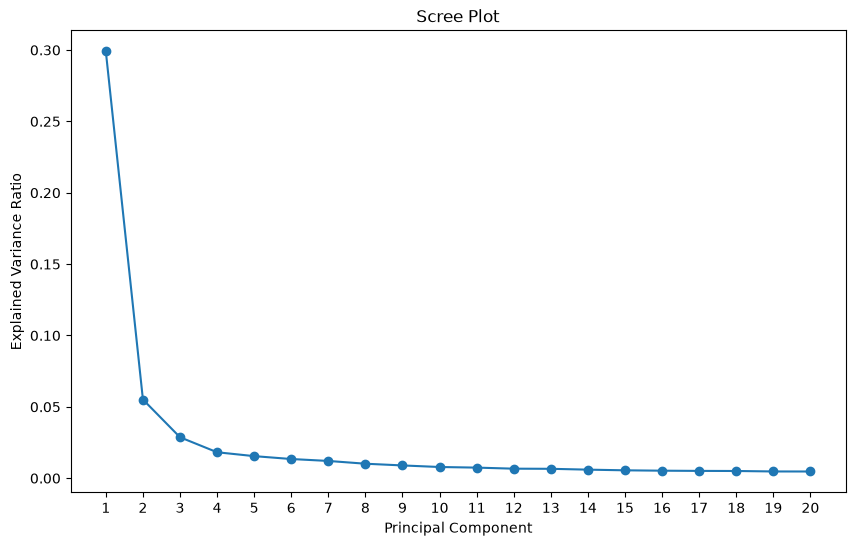

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), pca.explained_variance_ratio_[:20], marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, 21))
plt.show()

In [27]:
pca_4 = PCA(n_components=4)
pca_scores = pca_4.fit_transform(returns_scaled)
pca_scores.shape

(1258, 4)

In [28]:
loadings = pd.DataFrame(
    pca_4.components_.T,
    index=returns_clean.columns,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
loadings.shape

(468, 4)

In [29]:
loadings['PC1'].sort_values(ascending=False).head(10)

Name
BLK      0.068655
BRK.B    0.068024
PFG      0.067826
IVZ      0.067220
ITW      0.067050
HON      0.066450
TMK      0.066399
AMP      0.065805
BEN      0.065262
L        0.064381
Name: PC1, dtype: float64

In [30]:
loadings['PC1'].sort_values(ascending=True).head(10)

Name
NEM     0.011448
LNT     0.013643
NI      0.021458
ED      0.022266
CMG     0.025216
SO      0.025339
KORS    0.025779
SCG     0.026283
MAT     0.026295
PCG     0.026393
Name: PC1, dtype: float64

In [31]:
loadings['PC2'].sort_values(ascending=False).head(10)

Name
ED     0.152376
XEL    0.148687
WEC    0.148023
CMS    0.147492
SO     0.143461
DUK    0.143381
DTE    0.142738
PNW    0.142109
AEP    0.140443
AEE    0.134798
Name: PC2, dtype: float64

In [32]:
loadings['PC2'].sort_values(ascending=True).head(10)

Name
ZION   -0.085606
RF     -0.081565
CMA    -0.081330
BAC    -0.081237
LNC    -0.078456
SCHW   -0.078218
FITB   -0.074320
MET    -0.074120
HBAN   -0.073698
KEY    -0.073619
Name: PC2, dtype: float64

In [33]:
loadings['PC3'].sort_values(ascending=False).head(10)

Name
DVN    0.169727
HP     0.163687
MRO    0.159446
EOG    0.158844
APA    0.157973
HES    0.156017
COP    0.155872
APC    0.153907
NBL    0.153073
CXO    0.147931
Name: PC3, dtype: float64

In [34]:
loadings['PC3'].sort_values(ascending=True).head(10)

Name
DAL    -0.069014
LUV    -0.068369
UAL    -0.063292
NCLH   -0.062836
HSIC   -0.062491
ALK    -0.061685
CCL    -0.059476
CME    -0.056726
ABC    -0.056325
HOLX   -0.056005
Name: PC3, dtype: float64

In [35]:
loadings['PC4'].sort_values(ascending=False).head(10)

Name
PBCT    0.118802
MTB     0.116655
HBAN    0.109890
RF      0.108937
PNC     0.108507
KEY     0.108062
USB     0.106978
WFC     0.105597
FITB    0.105354
STI     0.105202
Name: PC4, dtype: float64

In [36]:
loadings['PC4'].sort_values(ascending=True).head(10)

Name
AVGO   -0.110311
AMAT   -0.106429
LRCX   -0.104109
MCHP   -0.098515
INCY   -0.098483
ILMN   -0.098187
MU     -0.097980
SWKS   -0.097101
COO    -0.094669
CRM    -0.092793
Name: PC4, dtype: float64

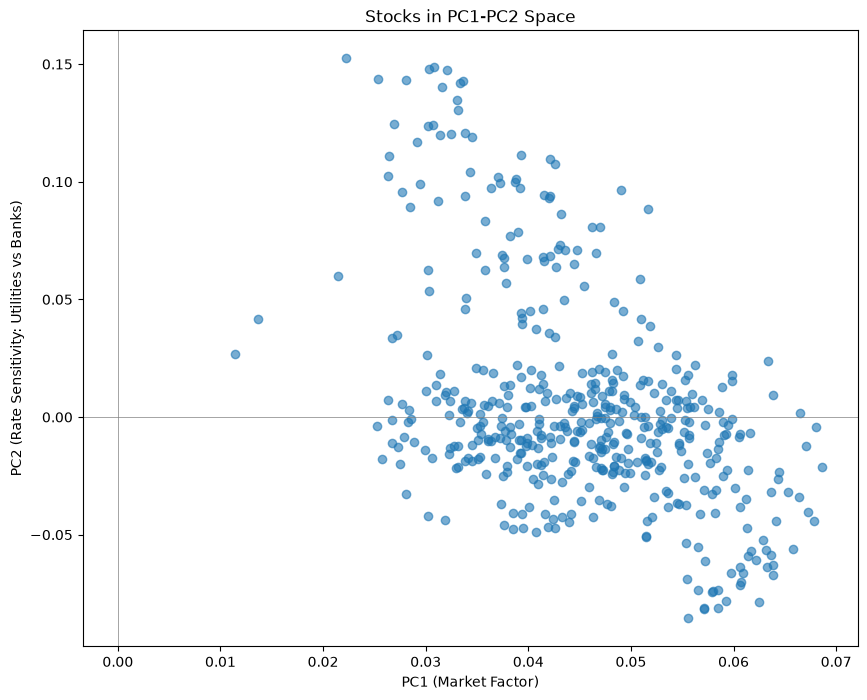

In [37]:
plt.figure(figsize=(10, 8))
plt.scatter(loadings['PC1'], loadings['PC2'], alpha=0.6)
plt.xlabel('PC1 (Market Factor)')
plt.ylabel('PC2 (Rate Sensitivity: Utilities vs Banks)')
plt.title('Stocks in PC1-PC2 Space')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()

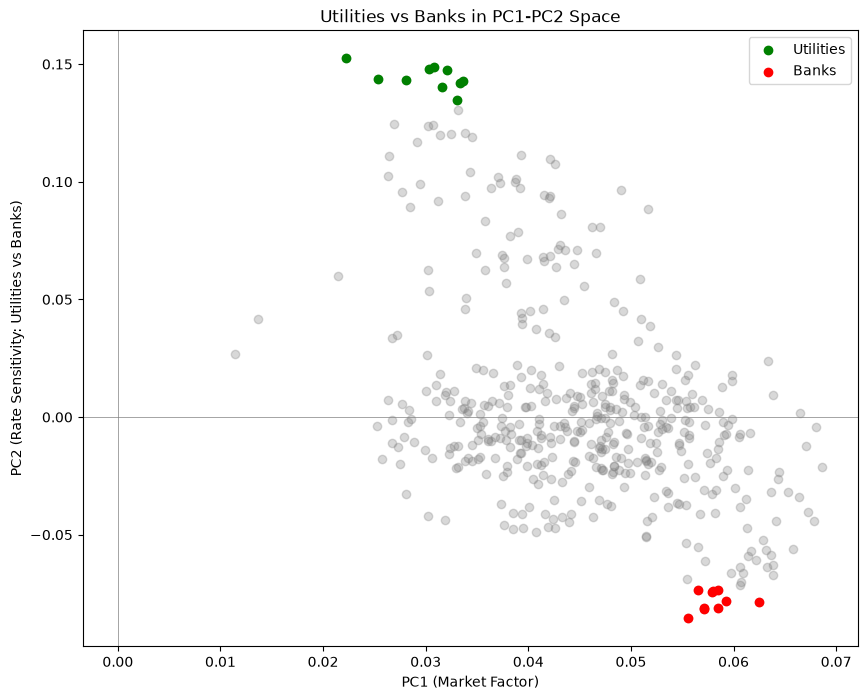

In [38]:
utilities = ['ED', 'XEL', 'WEC', 'CMS', 'SO', 'DUK', 'DTE', 'PNW', 'AEP', 'AEE']
banks = ['ZION', 'RF', 'CMA', 'BAC', 'LNC', 'SCHW', 'FITB', 'MET', 'HBAN', 'KEY']

plt.figure(figsize=(10, 8))
plt.scatter(loadings['PC1'], loadings['PC2'], alpha=0.3, color='gray')
plt.scatter(loadings.loc[utilities, 'PC1'], loadings.loc[utilities, 'PC2'], color='green', label='Utilities')
plt.scatter(loadings.loc[banks, 'PC1'], loadings.loc[banks, 'PC2'], color='red', label='Banks')
plt.xlabel('PC1 (Market Factor)')
plt.ylabel('PC2 (Rate Sensitivity: Utilities vs Banks)')
plt.title('Utilities vs Banks in PC1-PC2 Space')
plt.legend()
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()

In [39]:
loadings['PC1'].describe()

count    468.000000
mean       0.045069
std        0.010282
min        0.011448
25%        0.037625
50%        0.044731
75%        0.052677
max        0.068655
Name: PC1, dtype: float64

In [40]:
dropped = set(returns.columns) - set(returns_clean.columns)
sorted(dropped)

['ALLE',
 'APTV',
 'BHF',
 'BHGE',
 'BMY',
 'CFG',
 'COTY',
 'CSRA',
 'DHR',
 'DWDP',
 'DXC',
 'ES',
 'EVHC',
 'FOX',
 'FOXA',
 'FTV',
 'GOOG',
 'HLT',
 'HPE',
 'HPQ',
 'ICE',
 'INFO',
 'IQV',
 'KHC',
 'NAVI',
 'NWS',
 'NWSA',
 'O',
 'ORCL',
 'PYPL',
 'QRVO',
 'REGN',
 'SYF',
 'UA',
 'VRTX',
 'WLTW',
 'WRK']

In [41]:
import joblib

joblib.dump(scaler, 'market_factor_scaler.pkl')
joblib.dump(pca_4, 'market_factor_pca.pkl')

['market_factor_pca.pkl']